<a href="https://colab.research.google.com/github/dwaipayan05/CovCNN-WebApp/blob/main/COVID_Chest_X_Ray_(Xception).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# Point directly to your dataset folder on Windows
dataset_path = r"S:\CovCNN-WebApp\Dataset"
os.chdir(dataset_path)
print("Current working directory:", os.getcwd())


Current working directory: S:\CovCNN-WebApp\Dataset


**Import Necessary Libraries**

In [3]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import keras
from keras.utils import to_categorical
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.layers import  Flatten, Dense, Dropout
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.applications import Xception
from keras.models import Model
from keras.layers import Input
from keras import optimizers
from keras.optimizers import Adam
from keras.layers import Dense, GlobalAveragePooling2D
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
from keras import callbacks
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [4]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Device Name:", tf.test.gpu_device_name())
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
GPU Device Name: 
Num GPUs Available: 0


In [5]:
import os

# change to your dataset folder
os.chdir(r"S:\CovCNN-WebApp\Dataset")

# verify
print("Current directory:", os.getcwd())


Current directory: S:\CovCNN-WebApp\Dataset



**Fetch Dataset**

In [6]:
import os

# Change directory to your dataset
data_dir = r"S:\CovCNN-WebApp\Dataset"
os.chdir(data_dir)

print("✅ Current directory set to:", os.getcwd())

# Check folder structure
print("Folders inside dataset:")
print(os.listdir())


✅ Current directory set to: S:\CovCNN-WebApp\Dataset
Folders inside dataset:
['COVID', 'non-COVID', 'ResNet50_Model.keras', 'VGG16_Model.keras']


**Split Into Train Data & Test Data**

In [ ]:
# Define dataset folders correctly for your local system
disease_types = ['COVID', 'non-COVID']
data_dir = r"S:\CovCNN-WebApp\Dataset"   # ✅ Use your actual local folder path
train_dir = data_dir                     # no need to join again


In [17]:
import os
import pandas as pd

disease_types = ['COVID', 'non-COVID']
train_dir = r"S:\CovCNN-WebApp\Dataset"   # <-- Your local dataset path

train_data = []
for defects_id, sp in enumerate(disease_types):
    folder_path = os.path.join(train_dir, sp)
    
    # Just for confirmation
    print(f"📂 Reading files from: {folder_path}")
    
    for file in os.listdir(folder_path):
        train_data.append([f"{sp}/{file}", defects_id, sp])

train = pd.DataFrame(train_data, columns=['File', 'DiseaseID', 'Disease Type'])
print("✅ Data loaded successfully!")
print(train.head())


📂 Reading files from: S:\CovCNN-WebApp\Dataset\COVID
📂 Reading files from: S:\CovCNN-WebApp\Dataset\non-COVID
✅ Data loaded successfully!
                     File  DiseaseID Disease Type
0     COVID/Covid (1).png          0        COVID
1    COVID/Covid (10).png          0        COVID
2   COVID/Covid (100).png          0        COVID
3  COVID/Covid (1000).png          0        COVID
4  COVID/Covid (1001).png          0        COVID


In [18]:
IMAGE_SIZE = 64
def read_image(filepath):
    return cv2.imread(os.path.join(data_dir, filepath)) 
def resize_image(image, image_size):
    return cv2.resize(image.copy(), image_size, interpolation=cv2.INTER_AREA)

In [19]:
X_train = np.zeros((train.shape[0], IMAGE_SIZE, IMAGE_SIZE, 3))
for i, file in tqdm(enumerate(train['File'].values)):
    image = read_image(file)
    if image is not None:
        X_train[i] = resize_image(image, (IMAGE_SIZE, IMAGE_SIZE))
X_Train = X_train / 255.
print(X_Train.shape)

2481it [00:00, 33572.94it/s]

(2481, 64, 64, 3)


In [20]:
Y_train = train['DiseaseID'].values
Y_train = to_categorical(Y_train, num_classes=2)

In [21]:
X_train, X_val, Y_train, Y_val = train_test_split(X_Train, Y_train, test_size=0.2, random_state = 42)

**Define Xception Model Architecture**

In [22]:
BATCH_SIZE = 64
EPOCHS = 100
SIZE=64
N_ch=3

In [25]:
def build_Xception():
    xception = Xception(weights='imagenet', include_top=False)

    input = Input(shape=(SIZE, SIZE, N_ch))
    x = Conv2D(3, (3, 3), padding='same')(input)
    
    x = xception(x)
    
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    # multi output
    output = Dense(2,activation = 'softmax', name='root')(x)
 

    # model
    model = Model(input,output)
    
    optimizer = Adam(learning_rate=0.003, beta_1=0.9, beta_2=0.999, epsilon=0.1)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    model.summary()
    
    return model

**Train the Model**

In [30]:
model = build_Xception()
annealer = ReduceLROnPlateau(monitor='val_accuracy', factor=0.70, patience=5, verbose=1, min_lr=1e-4)
checkpoint = ModelCheckpoint('Xception_Model.keras', verbose=1, save_best_only=True)
datagen = ImageDataGenerator(rotation_range=360, 
                        width_shift_range=0.2, 
                        height_shift_range=0.2,
                        zoom_range=0.2, 
                        horizontal_flip=True, 
                        vertical_flip=True) 

datagen.fit(X_train)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 3)      │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 2, 2, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ root (Dense)                    │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,395,838 (81.62 MB)

 Trainable params: 21,336,702 (81.39 MB)

 Non-trainable params: 59,136 (231.00 KB)

In [31]:
history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=X_train.shape[0] // BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1,
    callbacks=[annealer, checkpoint],
    validation_data=(X_val, Y_val)
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4825 - loss: 0.6931
Epoch 1: val_loss improved from None to 0.75104, saving model to Xception_Model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.4899 - loss: 0.6931 - val_accuracy: 0.5191 - val_loss: 0.7510 - learning_rate: 0.0030
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5198 - loss: 0.6930
Epoch 2: val_loss did not improve from 0.75104
31/31 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.5106 - loss: 0.6931 - val_accuracy: 0.5191 - val_loss: 6.6157 - learning_rate: 0.0030
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5051 - loss: 0.6931
Epoch 3: val_loss did not improve from 0.75104
31/31 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.5106 - loss: 0.6930 - val_accuracy: 0.5191 - val_loss: 64.3664 - learning_rate: 0.0030
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5259 - loss: 0.6925
Epoch 4: val_loss did not improve from 0.75104
31/31 ━━━━━━━━━━━━━

**Plot the Results**

In [37]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

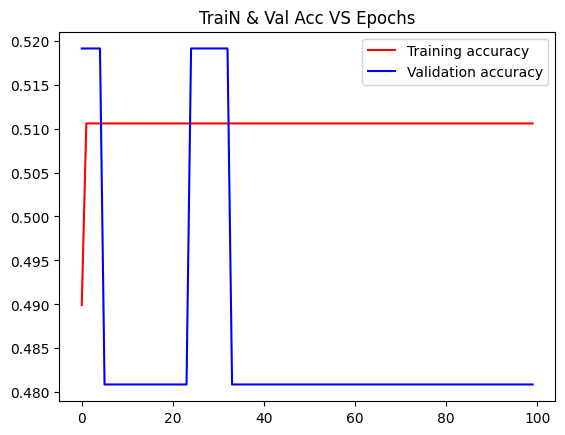

<Figure size 640x480 with 0 Axes>

In [38]:
epochs = range(len(acc))
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('TraiN & Val Acc VS Epochs')
plt.legend(loc=0)
plt.figure()
plt.show()

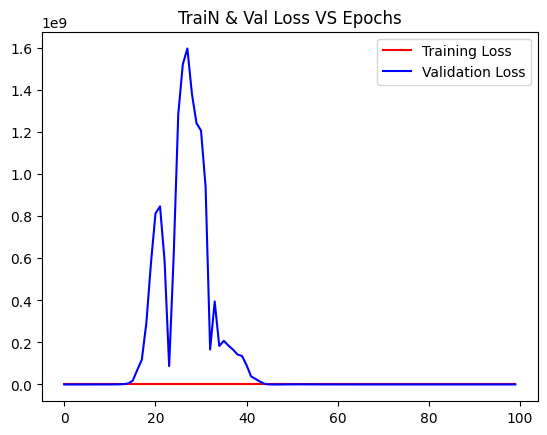

<Figure size 640x480 with 0 Axes>

In [39]:
epochs = range(len(acc))
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('TraiN & Val Loss VS Epochs')
plt.legend(loc=0)
plt.figure()
plt.show()

In [40]:
model.load_weights("Xception_Model.keras")  # ✅ correct
score = model.evaluate(X_val, Y_val ,verbose=1)
print('Test Loss:', score[0])
print('Test accuracy:', score[1]*100)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.5191 - loss: 0.7510
Test Loss: 0.751037061214447
Test accuracy: 51.91146731376648


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step


Text(0.5, 1.0, 'Confusion Matrix')

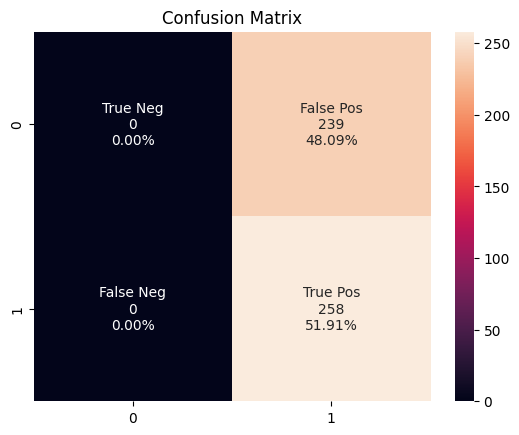

In [41]:
Y_pred = model.predict(X_val)
Y_predx = np.argmax(Y_pred, axis = -1)
Y_valx = np.argmax(Y_val, axis = -1)
cf_matrix = confusion_matrix(Y_valx, Y_predx)
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cf_matrix.flatten()/np.sum(cf_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(cf_matrix, annot = labels, fmt = '')
plt.title("Confusion Matrix")